# Exploratory Data Analysis

## Step 1: Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50) # This tells Pandas to show up to 50 columns before hiding the rest.
pd.set_option('display.max_colwidth', 80) # This tells Pandas to show up to 80 characters per cell before cutting off


## Step 2: Load the Data

In [4]:
df = pd.read_csv('../data/raw/developer-survey-2025.csv', low_memory=False)

# low_memory=False tells Pandas to read the ENTIRE file at once before deciding what data type each column is.
# Without this, Pandas reads in small chunks and
# can get confused when a column has mixed types (e.g. numbers AND text).
# It uses more RAM but gives us cleaner, more accurate results.

## Step 3: Inspect the Data

In [8]:
print(f'Shape of the data: {df.shape}') # .shape returns a tuple of (number of rows, number of columns).

print(f'In our dataset we have {df.shape[0]} rows and {df.shape[1]} columns')

Shape of the data: (49191, 172)
In our dataset we have 49191 rows and 172 columns


In [9]:
#preview the first 10 rows
df.head(10)

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantial addition to the tech stack",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,...,Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI agents have reduced the time sp...,AI agents have helped me automate repetitive tasks.;AI agents have improved ...,NaN,NaN,NaN,I am concerned about the accuracy of the information provided by AI agents.;...,Integrating AI agents with my existing tools and workflows can be difficult....,The cost of using certain AI agent platforms is a barrier.;I have concerns a...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Other online reso...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibility)",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,...,Not at all or minimally,NaN,NaN,NaN,NaN,NaN,NaN,NaN,It takes significant time and effort to learn how to use AI agents effective...,NaN,I am concerned about the accuracy of the information provided by AI agents.;...,Integrating AI agents with my existing tools and workflows can be difficult....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to fully understand something;Wh...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-employed",None of the above,10.0,"Yes, I am not new to coding but am learning new coding techniques or program...",Online Courses or Certification (includes all media types);Videos (not assoc...,"Yes, I learned how to use AI-enabled tools for my personal curiosity and/or ...",AI CodeGen tools or AI-enabled apps;Technical documentation (is generated fo...,12.0,"Developer, front-end",NaN,NaN,NaN,No,Work,12.0,2.0,3.0,7.0,5.0,10.0,13.0,...,"Yes, somewhat",Software engineering,Multi-platform search enablement,AI agents have increased my productivity.;AI agents have helped me automate ...,AI agents have improved the quality of my code.;AI agents have helped me sol...,AI agents have improved collaboration within my team.,NaN,NaN,It takes significant time and effort to learn how to use AI ag

In [10]:
# Get a summary of all the columns in the DataFrame (i.e name, data type and count of non-null values)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 176.2 MB


In [ ]:
# Statistical summary of numeric values

df.describe()

#   count  = how many non-missing values
#   mean   = average
#   std    = standard deviation (how spread out the values are)
#   min    = smallest value
#   25%    = 25th percentile (bottom quarter of values are below this)
#   50%    = median (the middle value — half are above, half below)
#   75%    = 75th percentile (top quarter of values are above this)
#   max    = largest value

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,JobSatPoints_1,JobSatPoints_2,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,ToolCountWork,ToolCountPersonal,CompTotal,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,34259.000000,34259.000000,34259.000000,34259.000000,34259.000000,34259.000000,34259.000000,34259.000000,34259.000000,34259.000000,24943.000000,24943.000000,...,24943.000000,24943.000000,24943.000000,24943.000000,24943.000000,24943.000000,24943.000000,24943.000000,24943.000000,24943.000000,27611.000000,25582.000000,2.486600e+04,26260.000000,24340.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,4.370841,4.431661,9.854315,8.307948,4.524067,5.925567,4.991710,4.048980,3.799323,4.365831,5.059867,5.508538,9.945766,6.867738,5.216173,...,8.194965,5.884096,7.367799,6.744658,7.512569,5.703283,8.563324,8.679349,14.687487,7.826685,17.734852,8.545579,2.234198e+70,4.907845,3.339770,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,2.357058,2.620901,1.975692,2.202164,2.282867,2.301937,2.294707,2.607443,2.499468,2.557152,2.533541,2.906146,2.087463,3.741490,3.660632,...,3.801257,3.900813,4.118532,3.888845,3.847265,4.110528,3.545288,3.633175,1.898188,4.077460,269.810134,44.664738,3.523096e+72,2.682204,2.411404,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,2.000000,2.000000,10.000000,8.000000,3.000000,4.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,10.000000,4.000000,2.000000,...,5.000000,2.000000,4.000000,3.000000,4.000000,2.000000,6.000000,6.000000,15.000000,4.000000,4.000000,3.000000,5.500000e+04,3.000000,1.000000,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,4.000000,4.000000,10.000000,9.000000,4.000000,6.000000,5.000000,4.000000,3.000000,4.000000,5.000000,6.000000,10.000000,6.000000,4.000000,...,8.000000,5.000000,7.000000,6.000000,7.000000,5.000000,9.000000,9.000000,15.000000,8.000000,6.000000,5.000000,1.050000e+05,5.000000,2.000000,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,6.000000,7.000000,10.000000,9.000000,6.000000,8.000000,7.000000,6.000000,6.000000,6.000000,7.000000,8.000000,10.000000,10.000000,8.000000,...,11.000000,9.000000,11.000000,10.00

## Step 3: Analyzing missing values

In [ ]:
df.isnull()
# df.isnull() returns a DataFrame of True/False values:
#   True  = this cell IS missing (null/NaN)
#   False = this cell has a value

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,True,True,False,False,False,True,True,True,True,False,True,True,True,False,True,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,True,True,True,True,True,True,True,False,True,False,False,True,True,True,True,True,True,True,True,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False,True,False,True,False,True,True,True,True,True,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True,False,False,True,True,True,True,True,True,True,False,True,False,True,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False,...,False,True,True,True,True,True,True,True,False,True,False,False,True,True,True,True,True,True,True,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49186,False,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
49187,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
49188,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False
49189,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [ ]:
df.isnull().sum() #.sum() then counts all the Trues in each column, (because True = 1 and False = 0 in Python, so summing counts the missing values)

ResponseId                 0
MainBranch                 0
Age                        0
EdLevel                 1042
Employment               852
                       ...  
AIAgentExtWrite        48332
AIHuman                19997
AIOpen                 26651
ConvertedCompYearly    25244
JobSat                 22521
Length: 172, dtype: int64

In [35]:
missing_count = df.isnull().sum().sort_values(ascending=False)

missing_pct = ((df.isnull().sum() / len(df)) * 100).round(1).sort_values(ascending=False)

missing_df = pd.DataFrame({'Missing_count': missing_count, 'Missing_%': missing_pct})

print('Top 30 columns with most missing values:')
missing_df[missing_df['Missing_count'] > 0].sort_values('Missing_%', ascending=False).head(30)

Top 30 columns with most missing values:


,Missing_count,Missing_%
AIAgentObsWrite,48927,99.5
SOTagsHaveEntry,48733,99.1
SOTagsWant Entry,48761,99.1
AIAgentOrchWrite,48713,99.0
AIModelsWantEntry,48716,99.0
JobSatPoints_15_TEXT,48527,98.7
AIAgentKnowWrite,48425,98.4
AIModelsHaveEntry,48415,98.4
AIAgentExtWrite,48332,98.3
SO_Actions_15_TEXT,48368,98.3


In [38]:
# --- Visualise missing values in our KEY columns only ---

# We focus on the columns that matter most for salary prediction.
# This is a list of the column names we care about.

key_cols = [
    'ConvertedCompYearly',  # Our TARGET - the salary we want to predict
    'Country',              # Where the developer works
    'YearsCode',            # Years of coding experience
    'WorkExp',              # Years of professional work experience
    'EdLevel',              # Education level
    'DevType',              # Type of developer (backend, frontend, etc.)
    'OrgSize',              # Company size
    'RemoteWork',           # Remote / hybrid / in-person
    'Employment',           # Full-time, freelance, etc.
    'Age',                  # Age bracket
    'JobSat'                # Job satisfaction score
]

# Calculate missing % for just these key columns
# df[key_cols] selects only those columns from our DataFrame

key_missing = (df[key_cols].isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)
key_missing

ConvertedCompYearly    51.3
JobSat                 45.8
RemoteWork             31.3
OrgSize                30.5
Country                28.0
WorkExp                12.8
YearsCode              12.5
DevType                11.2
EdLevel                 2.1
Employment              1.7
Age                     0.0
dtype: float64

C:\Users\JudyWambugu\AppData\Local\Temp\ipykernel_15008\1441130156.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=key_missing.values, y=key_missing.index, palette='Reds_r')


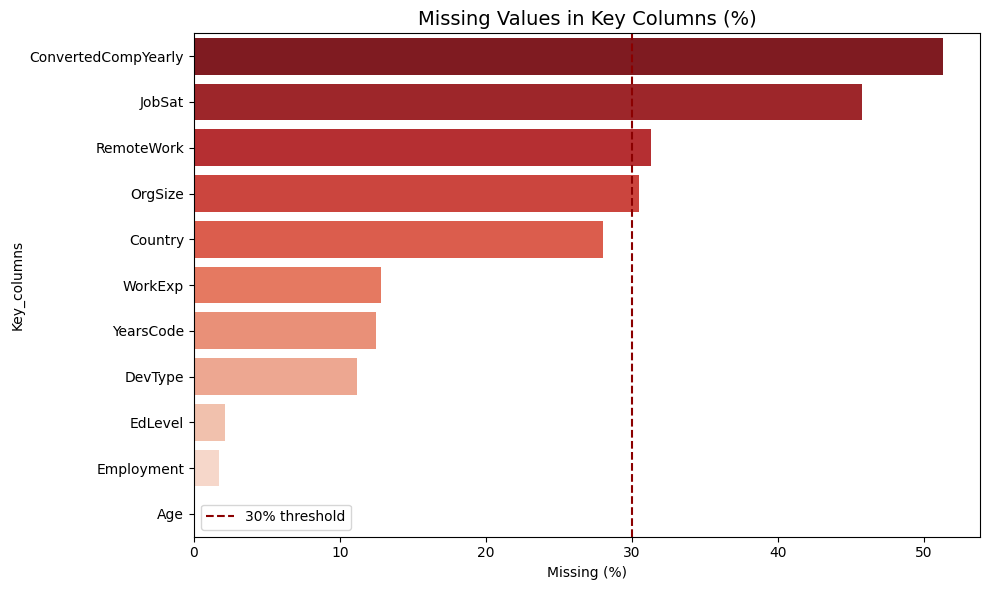

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x=key_missing.values, y=key_missing.index, palette='Reds_r')
plt.axvline(x=30, color='darkred', linestyle='--', linewidth=1.5, label='30% threshold')
plt.title('Missing Values in Key Columns (%)', fontsize=14)
plt.xlabel('Missing (%)')    # Label for the horizontal axis
plt.ylabel('Key_columns')         # Label for the vertical axis
plt.legend()                 # Show the legend (explains what the dashed line means)
plt.tight_layout()           # Automatically adjusts spacing so nothing gets cut off
plt.show()                   # Display the chart

## Step 4: Filter rows with salary data (our target variable)

In [46]:
df_salary = df[df['ConvertedCompYearly'].notna()].copy()

print(f'Original dataset:  {len(df):,} rows')
print(f'With salary data:  {len(df_salary):,} rows')
print(f'Rows dropped:      {len(df) - len(df_salary):,} rows ({(len(df)-len(df_salary))/len(df)*100:.1f}%)')

Original dataset:  49,191 rows
With salary data:  23,947 rows
Rows dropped:      25,244 rows (51.3%)


## Step 5: Explore the Target Variable (Salary Distribution)

In [47]:

print('Salary Statistics (USD per year):')
print('-' * 40)

salary = df_salary['ConvertedCompYearly']

print(f"Count:      {salary.count():,.0f} respondents")
print(f"Mean:       ${salary.mean():,.0f}")
print(f"Median:     ${salary.median():,.0f}")
print(f"Std Dev:    ${salary.std():,.0f}")
print(f"Min:        ${salary.min():,.0f}")
print(f"Max:        ${salary.max():,.0f}")
print(f"25th pct:   ${salary.quantile(0.25):,.0f}")
print(f"75th pct:   ${salary.quantile(0.75):,.0f}")

print()
print(f'NOTE: Mean (${salary.mean():,.0f}) is much higher than Median (${salary.median():,.0f})')
print('This confirms the data is RIGHT-SKEWED — a few very high earners pull the mean up.')

Salary Statistics (USD per year):
----------------------------------------
Count:      23,947 respondents
Mean:       $101,762
Median:     $75,320
Std Dev:    $461,757
Min:        $1
Max:        $50,000,000
25th pct:   $38,171
75th pct:   $120,596

NOTE: Mean ($101,762) is much higher than Median ($75,320)
This confirms the data is RIGHT-SKEWED — a few very high earners pull the mean up.


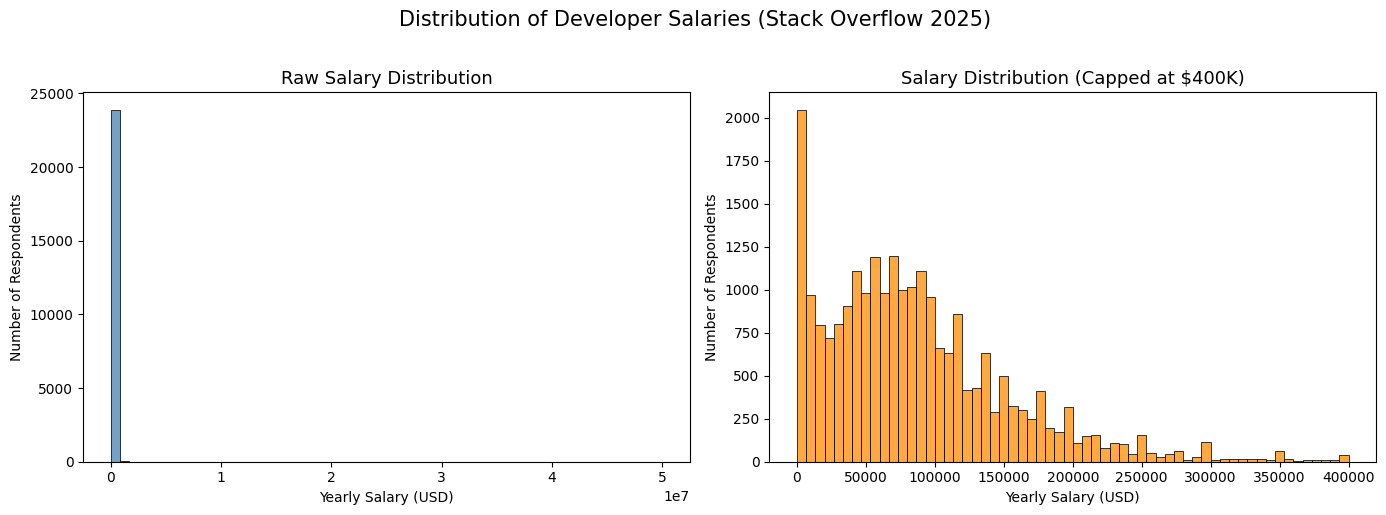

In [51]:
# Visualize the salary data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_salary, x='ConvertedCompYearly', bins=60, color='steelblue', ax=axes[0])
axes[0].set_title('Raw Salary Distribution', fontsize=13)
axes[0].set_xlabel('Yearly Salary (USD)')
axes[0].set_ylabel('Number of Respondents')

salary_capped = df_salary[df_salary['ConvertedCompYearly'] <= 400000]
sns.histplot(data=salary_capped, x='ConvertedCompYearly', bins=60, color='darkorange', ax=axes[1])
axes[1].set_title('Salary Distribution (Capped at $400K)', fontsize=13)
axes[1].set_xlabel('Yearly Salary (USD)')
axes[1].set_ylabel('Number of Respondents')

plt.suptitle('Distribution of Developer Salaries (Stack Overflow 2025)', fontsize=15, y=1.02)

plt.tight_layout()
plt.show()